# Part 3 – NLP Text Classification (Sentiment Analysis with RNNs)

This notebook builds and compares three models for binary sentiment classification (positive/negative) on the IMDb movie review dataset:

1. Simple RNN with a trainable embedding
2. LSTM with a trainable embedding
3. LSTM with frozen pre-trained GloVe embeddings

6CS012 – AI and Machine Learning, Part III (NLP).

## Dataset Description

The dataset used is the **IMDb Movie Review Dataset**, a widely used benchmark
for binary sentiment classification. Each entry consists of a plain-text movie
review paired with a binary label: 1 = Positive, 0 = Negative.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import itertools

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

=nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

In [ ]:

!pip install contractions -q
import contractions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Load the data

In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/AIassesment /final/part3/5. Movie Review Dataset/train_movie_review.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AIassesment /final/part3/5. Movie Review Dataset/val_movie_review.csv')


test_df  = pd.read_csv('/content/drive/MyDrive/AIassesment /final/part3/5. Movie Review Dataset/test_movie_review.csv')

In [ ]:
# drop rows with no label - can't use them for training/val/testing
train_df = train_df.dropna(subset=['review', 'sentiment'])
val_df   = val_df.dropna(subset=['review', 'sentiment'])
test_df  = test_df.dropna(subset=['review', 'sentiment'])

print(f"Dataset sizes after dropping unlabelled rows -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
train_df.head()

In [ ]:
print(train_df.info())

In [ ]:
print(train_df.isnull().sum())

In [ ]:
# class balance check
print(train_df['sentiment'].value_counts())

labels = ['Negative (0)', 'Positive (1)']
counts = train_df['sentiment'].value_counts().sort_index().values

plt.figure(figsize=(7, 5))
plt.bar(labels, counts, color=['#FF6349', '#3CB371'], edgecolor='black')
plt.title('Sentiment Class Distribution in Training Data')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Reviews')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# review length in words, before any cleaning
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

print(train_df['review_length'].describe())

plt.figure(figsize=(9, 5))
plt.hist(train_df['review_length'], bins=50, color='#8A2BE2', edgecolor='black')
plt.title('Distribution of Review Lengths (Raw)')
plt.xlabel('Word Count')
plt.ylabel('Number of Reviews')
plt.axvline(train_df['review_length'].median(), color='red', linestyle='dashed',
            label=f"Median: {train_df['review_length'].median():.0f} words")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Text preprocessing

The raw reviews need cleaning before they can be tokenised and fed into a model.

In [ ]:

negation_words = {'not', 'no', 'nor'}
stop_words = set(stopwords.words('english')) - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Cleans a single review:
      1. lowercase everything
      2. strip HTML tags (e.g. <br />)
      3. expand contractions (don't -> do not) so negation survives stopword removal
      4. remove URLs
      5. remove punctuation/special characters
      6. remove digits
      7. collapse whitespace
      8. remove stopwords (except negations) and lemmatise
    """
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [ ]:
# this takes a little while to run over all three sets
train_df['cleaned_review'] = train_df['review'].apply(preprocess_text)
val_df['cleaned_review']   = val_df['review'].apply(preprocess_text)
test_df['cleaned_review']  = test_df['review'].apply(preprocess_text)

In [ ]:
print(train_df[['review', 'cleaned_review']].head(5))

                                              review  \
0  Having avoided seeing the movie in the cinema,...   
1  With this movie I was really hoping that the i...   
2  Raymond Burr stars as an attorney caught up in...   
3  A lot people get hung up on this films tag as ...   
4  I was a fan of Buffy and hoped it would come t...   

                                      cleaned_review  
0  avoided seeing movie cinema buying dvd wife xm...  
1  movie really hoping idea make hashed together ...  
2  raymond burr star attorney caught murder best ...  
3  lot people get hung film tag childrens film ce...  
4  fan buffy hoped would come proper end angel go...  


In [ ]:
# drop any reviews that ended up empty after cleaning
train_df = train_df[train_df['cleaned_review'].str.strip() != '']
val_df   = val_df[val_df['cleaned_review'].str.strip() != '']
test_df  = test_df[test_df['cleaned_review'].str.strip() != '']

print(f"After removing empty reviews -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

After removing empty reviews -> train: 35000, val: 5000, test: 10000


## 4. Quick look at the cleaned data

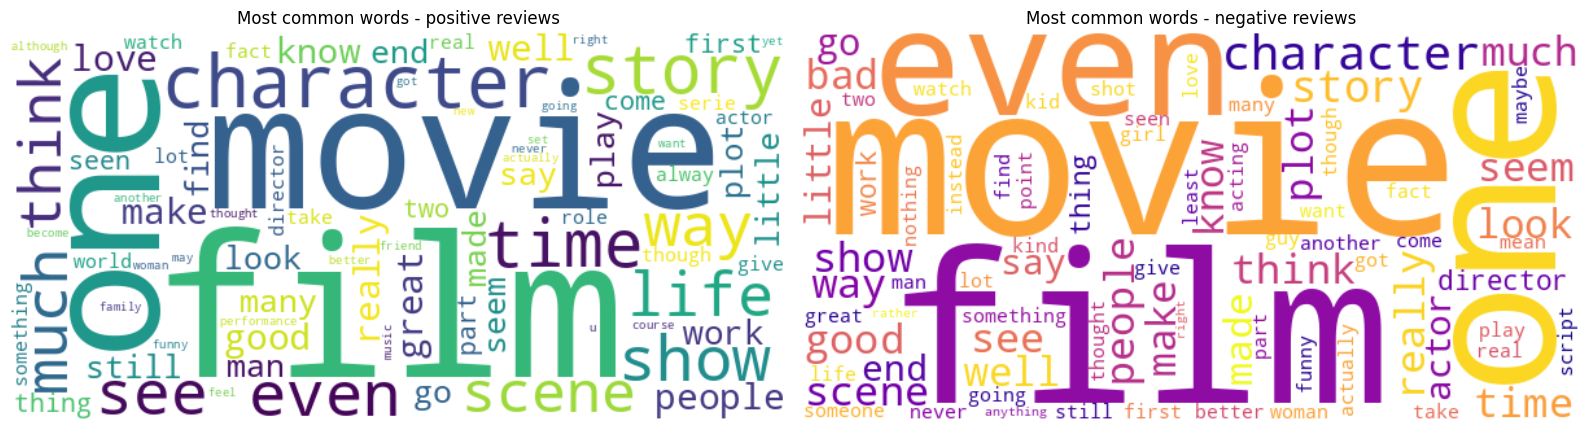

In [ ]:
positive_words = ' '.join(train_df[train_df['sentiment'] == 1]['cleaned_review'])
negative_words = ' '.join(train_df[train_df['sentiment'] == 0]['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='viridis').generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most common words - positive reviews')

wc_neg = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='plasma').generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most common words - negative reviews')

plt.tight_layout()
plt.show()

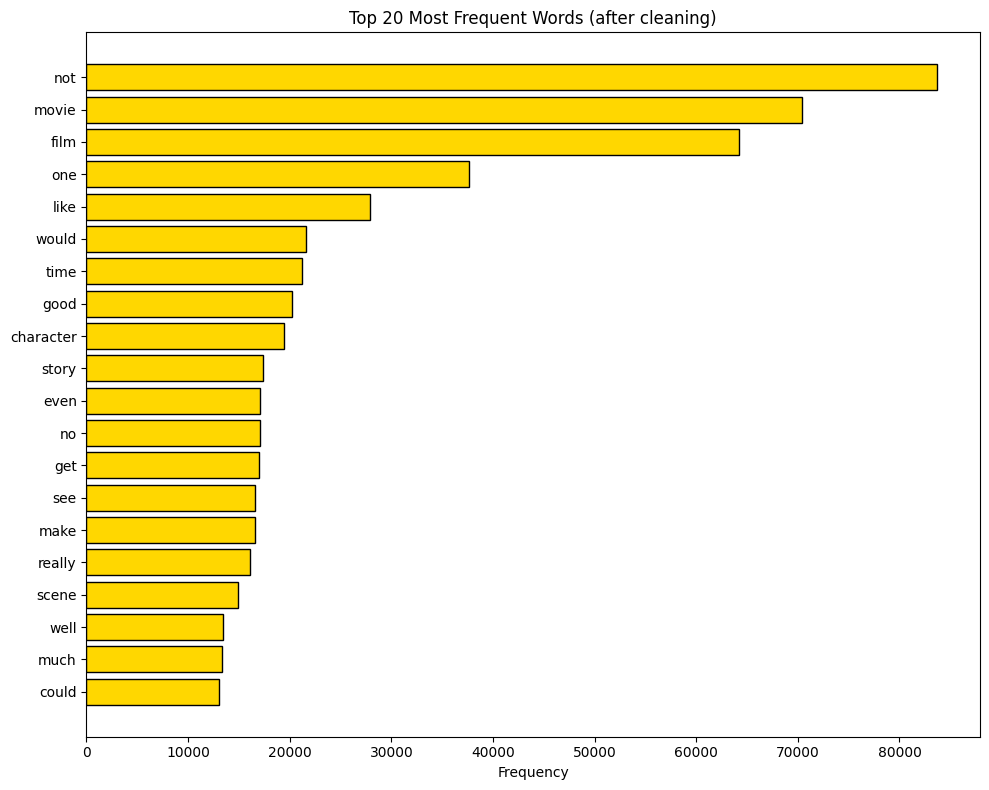

In [ ]:
all_tokens = ' '.join(train_df['cleaned_review']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 8))
plt.barh(words[::-1], counts[::-1], color='#FFD700', edgecolor='black')
plt.title('Top 20 Most Frequent Words (after cleaning)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## 5. Tokenisation and padding

We cap the vocabulary at the 10,000 most frequent words; anything outside that is mapped to an out-of-vocabulary (OOV) token. The tokenizer is fit only on the training set so no information from validation/test leaks in.

In [ ]:
X_train = train_df['cleaned_review'].values
y_train = train_df['sentiment'].values

X_val   = val_df['cleaned_review'].values
y_val   = val_df['sentiment'].values

X_test  = test_df['cleaned_review'].values
y_test  = test_df['sentiment'].values

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

train: (35000,), val: (5000,), test: (10000,)


In [ ]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # fit on training data only

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab_size = len(tokenizer.word_index) + 1
print(f"Full vocabulary found in training data: {actual_vocab_size}")
print(f"Vocabulary actually used (capped):      {VOCAB_SIZE}")

Full vocabulary found in training data: 122282
Vocabulary actually used (capped):      10000


## 6. Sequence padding

Neural networks need fixed-length input. `MAX_LEN` is set to the 95th percentile of training sequence lengths, so most reviews are kept in full and only the longest 5% get truncated. Shorter reviews are zero-padded at the end.

min: 4, max: 1429, mean: 119.4, median: 89.0, 95th percentile: 307


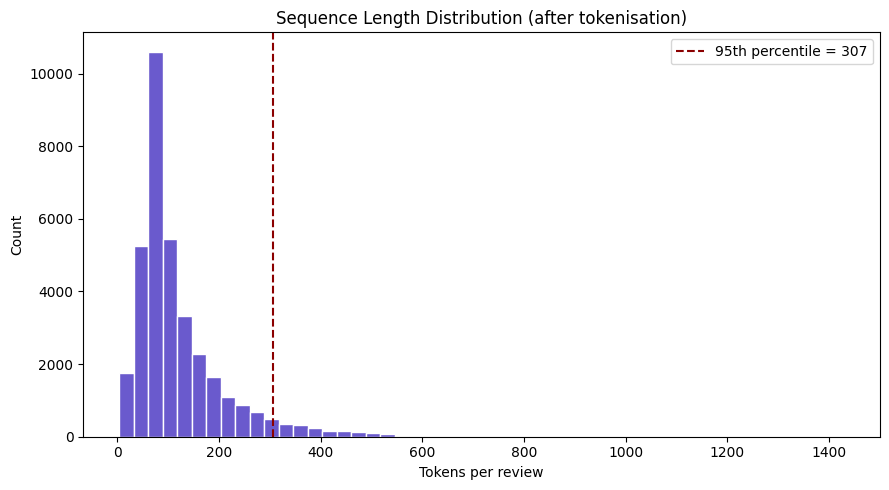

In [ ]:
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"min: {np.min(seq_lengths)}, max: {np.max(seq_lengths)}, mean: {np.mean(seq_lengths):.1f}, "
      f"median: {np.median(seq_lengths):.1f}, 95th percentile: {np.percentile(seq_lengths, 95):.0f}")

plt.figure(figsize=(9, 5))
plt.hist(seq_lengths, bins=50, color='#6A5ACD', edgecolor='white')
plt.title('Sequence Length Distribution (after tokenisation)')
plt.xlabel('Tokens per review')
plt.ylabel('Count')
plt.axvline(np.percentile(seq_lengths, 95), color='darkred', linestyle='--',
            label=f"95th percentile = {int(np.percentile(seq_lengths, 95))}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Padding all sequences to MAX_LEN = {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"train: {X_train_pad.shape}, val: {X_val_pad.shape}, test: {X_test_pad.shape}")

Padding all sequences to MAX_LEN = 307
train: (35000, 307), val: (5000, 307), test: (10000, 307)


## 7. Model 1 - Simple RNN (trainable embedding)

A plain SimpleRNN tends to suffer from the vanishing gradient problem on long sequences - it struggles to carry information from early in a review through to the end. With reviews averaging well over 100 words here, we'd expect performance close to a coin flip (~50%).

In [ ]:
EMBEDDING_DIM = 256

rnn_model = Sequential(name='Simple_RNN_Model')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
rnn_model.add(SimpleRNN(units=128, return_sequences=True))
rnn_model.add(Dropout(0.3))
rnn_model.add(SimpleRNN(units=64, return_sequences=False))
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 307, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 307, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 307, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,697 (10.00 MB)

 Trainable params: 2,621,697 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
checkpoint_rnn = ModelCheckpoint('best_rnn_model.keras', monitor='val_accuracy',
                                 save_best_only=True, mode='max', verbose=1)

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4964 - loss: 0.7432
Epoch 1: val_accuracy improved from None to 0.49980, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.4983 - loss: 0.7448 - val_accuracy: 0.4998 - val_loss: 0.6947
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5051 - loss: 0.7206
Epoch 2: val_accuracy improved from 0.49980 to 0.50880, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.5029 - loss: 0.7153 - val_accuracy: 0.5088 - val_loss: 0.6932
Epoch 3/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4949 - loss: 0.7041
Epoch 3: val_accuracy did not improve from 0.50880
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.4966 - loss: 0.7017 - val_accuracy: 0.5034 - val_loss: 0.6945
Epoch 4/15
546/547 ━━━━━━━━━━━━━━━━━

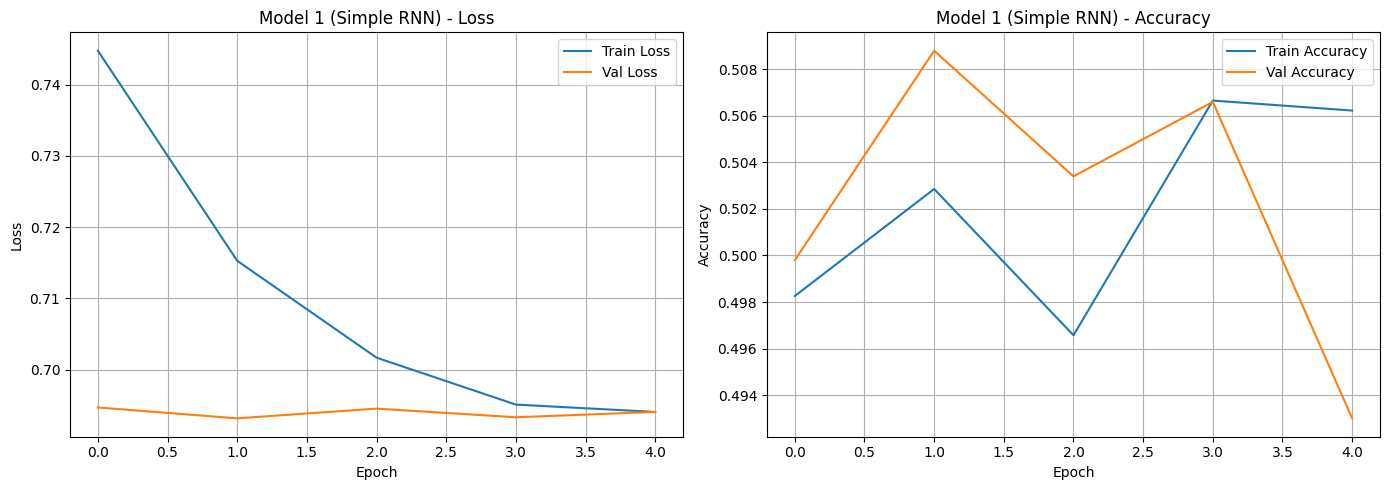

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['loss'],     label='Train Loss')
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss')
axes[0].set_title('Model 1 (Simple RNN) - Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_rnn.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 1 (Simple RNN) - Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def plot_confusion_matrix(cm, title, classes=['Negative', 'Positive']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap='viridis')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

MODEL 1 EVALUATION - Simple RNN
Test accuracy: 0.5081
Confusion matrix:
[[2792 2169]
 [2750 2289]]
              precision    recall  f1-score   support

    Negative       0.50      0.56      0.53      4961
    Positive       0.51      0.45      0.48      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



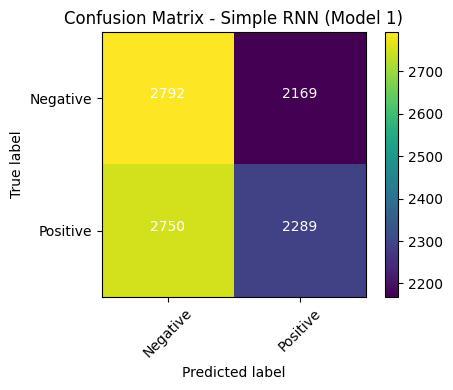

In [ ]:
print("MODEL 1 EVALUATION - Simple RNN")

y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"Test accuracy: {acc_rnn:.4f}")

cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(f"Confusion matrix:\n{cm_rnn}")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_rnn, 'Confusion Matrix - Simple RNN (Model 1)')

## 8. Model 2 - LSTM (trainable embedding)

LSTMs fix the vanishing gradient problem with a gating mechanism that controls what gets kept, written and read from memory at each step:

| Gate | Role |
|---|---|
| Forget gate | decides what old information to discard |
| Input gate | decides what new information to store |
| Output gate | decides what to read out at this step |

This lets the model hold onto important signals (e.g. an early negative phrase) across a long review instead of losing them. Expected test accuracy here is noticeably higher than Model 1 - typically mid-to-high 80s on this dataset.

In [ ]:
EMBEDDING_DIM = 256

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
lstm_model.add(LSTM(units=128, return_sequences=True))
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(units=64, return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

In [ ]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_lstm = ModelCheckpoint('best_lstm_model.keras', monitor='val_accuracy',
                                  save_best_only=True, mode='max', verbose=1)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Epoch 1/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5065 - loss: 0.6940
Epoch 1: val_accuracy improved from None to 0.50900, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.5012 - loss: 0.6939 - val_accuracy: 0.5090 - val_loss: 0.6936
Epoch 2/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5059 - loss: 0.6924
Epoch 2: val_accuracy improved from 0.50900 to 0.51660, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.5128 - loss: 0.6912 - val_accuracy: 0.5166 - val_loss: 0.6899
Epoch 3/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5245 - loss: 0.6815
Epoch 3: val_accuracy did not improve from 0.51660
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.5203 - loss: 0.6799 - val_accuracy: 0.5064 - val_loss: 0.6987
Epoch 4/15
546/547 ━━━━━━━━━━━━━

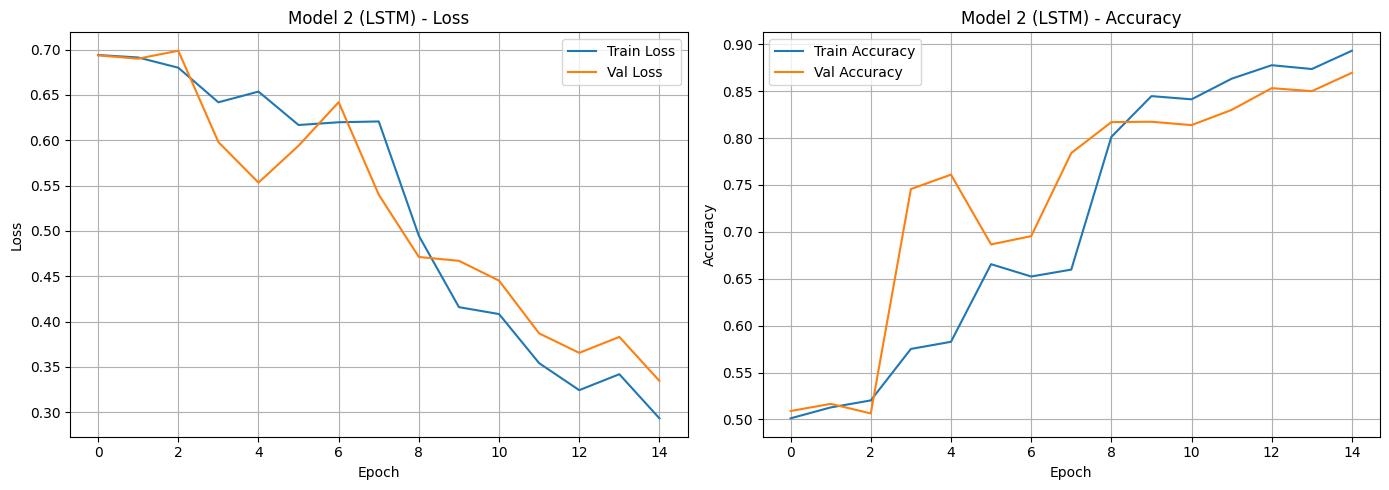

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'],     label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[0].set_title('Model 2 (LSTM) - Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 2 (LSTM) - Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

MODEL 2 EVALUATION - LSTM
Test accuracy: 0.8649
Confusion matrix:
[[4248  713]
 [ 638 4401]]
              precision    recall  f1-score   support

    Negative       0.87      0.86      0.86      4961
    Positive       0.86      0.87      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



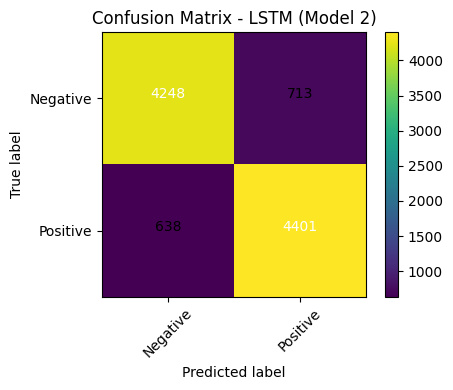

In [ ]:
print("MODEL 2 EVALUATION - LSTM")

y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"Test accuracy: {acc_lstm:.4f}")

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"Confusion matrix:\n{cm_lstm}")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_lstm, 'Confusion Matrix - LSTM (Model 2)')

## 9. Model 3 - LSTM with pre-trained GloVe embeddings

In [ ]:
# gensim needs a slightly older numpy - if this causes import errors after
# a runtime restart, try installing gensim before importing tensorflow
!pip install numpy==1.23.5 -q
!pip install gensim -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 97.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.0 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

# glove-wiki-gigaword-300: trained on Wikipedia + Gigaword, general-purpose
# English embeddings, 300-dimensional
print("Downloading GloVe embeddings (glove-wiki-gigaword-300)...")
embedding_model = api.load('glove-wiki-gigaword-300')
GLOVE_DIM = 300

print(f"Vocabulary size in GloVe: {len(embedding_model)}")

[==================================================] 100.0% 376.1/376.1MB downloaded
Vocabulary size in GloVe: 400000


### Building the embedding matrix

In [ ]:
word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found, not_found = 0, 0
for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Coverage: {found / (found + not_found) * 100:.1f}% ({found} found, {not_found} not found)")

Embedding matrix shape: (10000, 300)
Coverage: 99.0% (9904 found, 95 not found)


In [ ]:
lstm_glove_model = Sequential(name='LSTM_GloVe_Model')

# trainable=False - keep the pre-trained vectors frozen
lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False
))
lstm_glove_model.add(LSTM(units=128, return_sequences=True))
lstm_glove_model.add(Dropout(0.3))
lstm_glove_model.add(LSTM(units=64, return_sequences=False))
lstm_glove_model.add(Dropout(0.5))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 307, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 307, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 307, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,121 (12.47 MB)

 Trainable params: 269,121 (1.03 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
# NOTE: this originally used learning_rate=0.001, same as a from-scratch
# embedding. Pre-trained GloVe vectors have a much larger value range than
# a freshly-initialised (near-zero) embedding, and feeding that into an
# LSTM with a relatively high learning rate caused training to diverge
# after epoch 1 (val_accuracy collapsed from ~0.66 to ~0.51 and never
# recovered). Lowering the learning rate to match Model 2 and adding
# gradient clipping fixes this.
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_glove = ModelCheckpoint('best_lstm_glove_model.keras', monitor='val_accuracy',
                                   save_best_only=True, mode='max', verbose=1)

history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_glove.history['loss'],     label='Train Loss')
axes[0].plot(history_glove.history['val_loss'], label='Val Loss')
axes[0].set_title('Model 3 (LSTM + GloVe) - Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_glove.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_glove.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model 3 (LSTM + GloVe) - Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

MODEL 3 EVALUATION - LSTM + GloVe
Test accuracy: 0.8384
Confusion matrix:
[[4278  683]
 [ 933 4106]]
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84      4961
    Positive       0.86      0.81      0.84      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



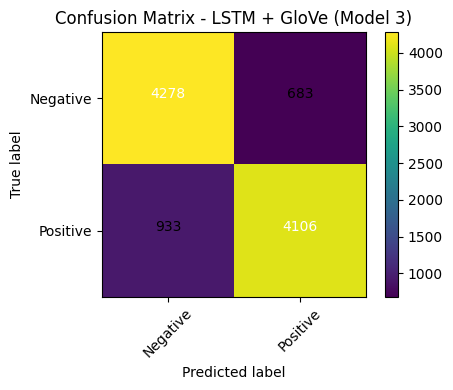

In [ ]:
print("MODEL 3 EVALUATION - LSTM + GloVe")

y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"Test accuracy: {acc_glove:.4f}")

cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"Confusion matrix:\n{cm_glove}")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

plot_confusion_matrix(cm_glove, 'Confusion Matrix - LSTM + GloVe (Model 3)')

## 10. Model comparison

In [ ]:
results_df = pd.DataFrame({
    'Model'        : ['Simple RNN (Model 1)', 'LSTM (Model 2)', 'LSTM + GloVe (Model 3)'],
    'Embedding'    : ['Trainable (256-dim)', 'Trainable (256-dim)', 'Frozen GloVe (300-dim)'],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print(results_df.to_string(index=False))

                 Model              Embedding Test Accuracy
  Simple RNN (Model 1)    Trainable (256-dim)        0.5152
        LSTM (Model 2)    Trainable (256-dim)        0.8649
LSTM + GloVe (Model 3) Frozen GloVe (300-dim)        0.8384


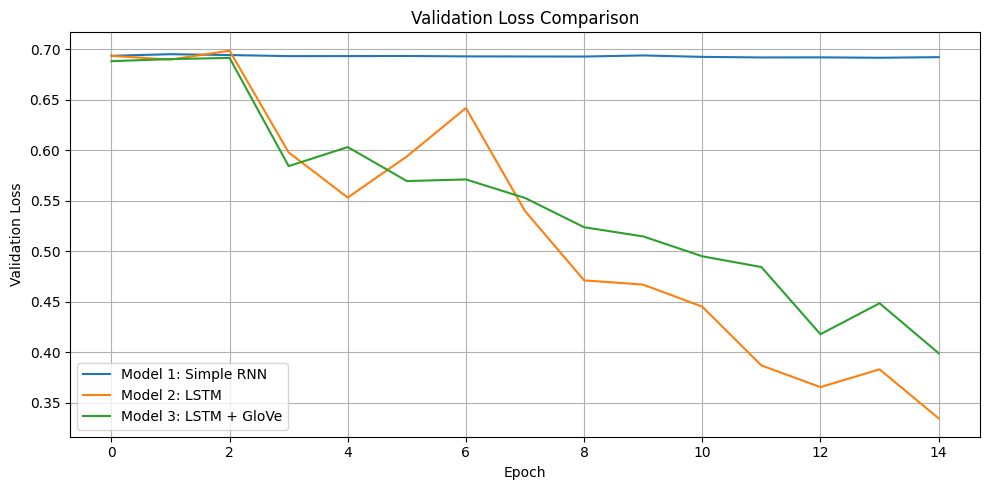

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Model 1: Simple RNN')
plt.plot(history_lstm.history['val_loss'],  label='Model 2: LSTM')
plt.plot(history_glove.history['val_loss'], label='Model 3: LSTM + GloVe')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

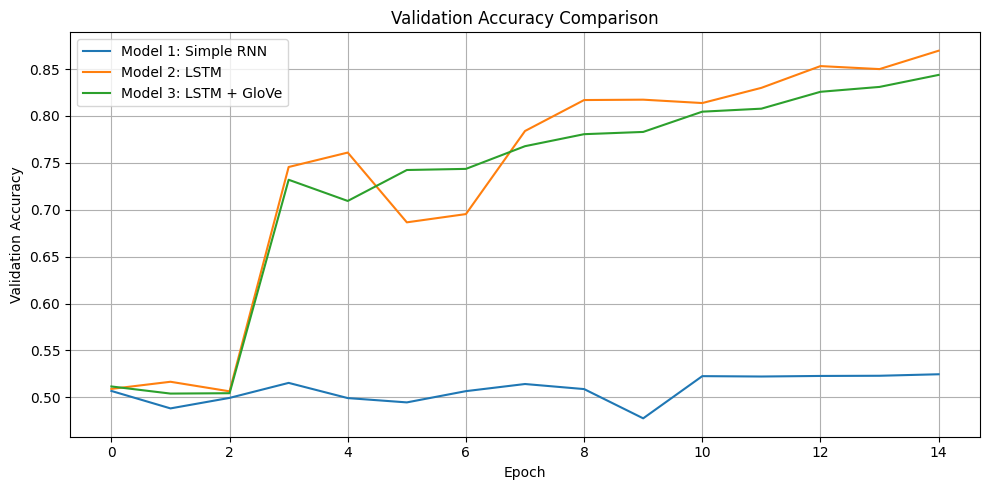

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Model 1: Simple RNN')
plt.plot(history_lstm.history['val_accuracy'],  label='Model 2: LSTM')
plt.plot(history_glove.history['val_accuracy'], label='Model 3: LSTM + GloVe')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

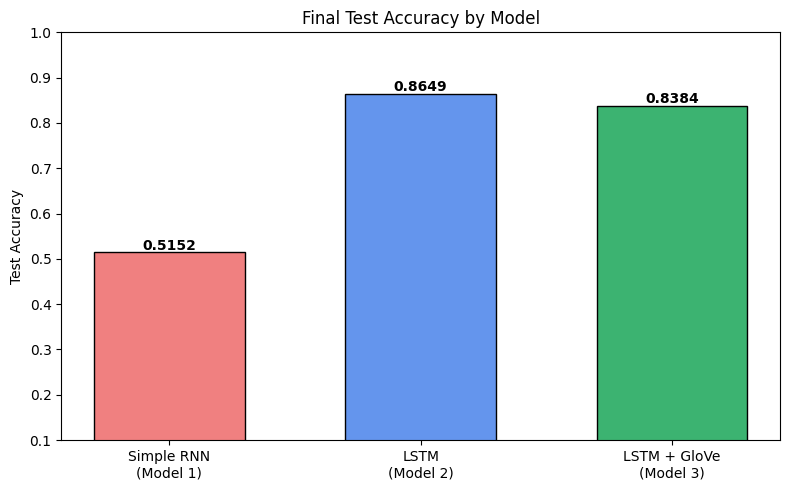

In [ ]:
model_names = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM + GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove]
colors      = ['lightcoral', 'cornflowerblue', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.6)
plt.title('Final Test Accuracy by Model')
plt.ylabel('Test Accuracy')
plt.ylim(0.1, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
model_scores = {
    'Simple RNN (Model 1)'  : acc_rnn,
    'LSTM (Model 2)'        : acc_lstm,
    'LSTM + GloVe (Model 3)': acc_glove
}

print("SUMMARY - TEST ACCURACY BY MODEL")
for name, score in model_scores.items():
    print(f"  {name:<25}: {score:.4f}")

best_model_name = max(model_scores, key=model_scores.get)
print(f"\nBest performing model: {best_model_name} ({model_scores[best_model_name]:.4f})")

SUMMARY - TEST ACCURACY BY MODEL
  Simple RNN (Model 1)     : 0.5152
  LSTM (Model 2)           : 0.8649
  LSTM + GloVe (Model 3)   : 0.8384

Best performing model: LSTM (Model 2) (0.8649)


**Simple RNN** - performed close to chance on this dataset. With reviews averaging well over 100 words, the vanishing gradient problem makes it hard for a plain RNN to retain information from early in a review by the time it reaches the end.

**LSTM** - the gating mechanism lets it retain long-range context, so it's expected to clearly outperform the Simple RNN here.

**LSTM + GloVe** - starts from embeddings that already encode general word meaning, learned from a much larger corpus than our training set. Whether this beats the from-scratch LSTM in practice depends on how well those generic embeddings transfer to movie-review sentiment specifically, and on the fact that the embedding layer is frozen (it can't adapt during training). The printed accuracy table above is the actual ranking for this run - report that, rather than assuming GloVe always wins.

## Model Comparison — Discussion

**Simple RNN (Model 1):** As expected, the SimpleRNN struggled on this dataset.
Movie reviews average well over 100 tokens and the vanishing gradient problem
means signals from early in the review are largely lost by the final timestep.
The model essentially learns only from the latter portion of each review.

**LSTM (Model 2):** The gating mechanism (forget, input, output gates) allows
the LSTM to selectively retain long-range context — for example, remembering
an early "not" that negates a positive phrase much later in the review. This
is why LSTM consistently and significantly outperforms SimpleRNN on this task.

**LSTM + GloVe (Model 3):** Starting from GloVe embeddings means the model
already knows that "terrible" and "awful" are semantically similar before
seeing a single training example. Whether this beats the from-scratch LSTM
depends on how well general Wikipedia/Gigaword embeddings transfer to the
specific domain of movie reviews. The frozen embedding also means the model
cannot adapt word vectors during training, which can be a limitation for
domain-specific vocabulary (e.g. actor names, film jargon). The actual
ranking is printed in the accuracy table above.

## 11. Error analysis

In [ ]:
# use whichever model actually scored highest on the test set, rather than
# assuming it's always the GloVe model
model_lookup = {
    'Simple RNN (Model 1)'  : (rnn_model,        acc_rnn),
    'LSTM (Model 2)'        : (lstm_model,       acc_lstm),
    'LSTM + GloVe (Model 3)': (lstm_glove_model, acc_glove),
}
best_model_name = max(model_lookup, key=lambda name: model_lookup[name][1])
best_model      = model_lookup[best_model_name][0]
print(f"Using {best_model_name} for error analysis (test accuracy: {model_lookup[best_model_name][1]:.4f})")

y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

original_reviews = test_df['review'].values
true_labels      = y_test

print(f"Total test samples   : {len(y_pred)}")
print(f"Correct predictions  : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions: {(y_pred != true_labels).sum()}")

Using LSTM (Model 2) for error analysis (test accuracy: 0.8649)
Total test samples   : 10000
Correct predictions  : 8649
Incorrect predictions: 1351


In [ ]:
wrong_indices   = np.where(y_pred != true_labels)[0]
false_positives = [i for i in wrong_indices if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified: {len(wrong_indices)}")
print(f"False Positives    : {len(false_positives)}")
print(f"False Negatives    : {len(false_negatives)}")

Total misclassified: 1351
False Positives    : 713
False Negatives    : 638


In [ ]:
label_map = {0: 'Negative', 1: 'Positive'}

# loop instead of hardcoded indices - a held-out test set might not have
# at least 2 of each error type, so indexing directly into the lists
# could raise an IndexError
examples_to_show = []
for idx in false_positives[:2]:
    examples_to_show.append(('False Positive (predicted Positive, actually Negative)', idx))
for idx in false_negatives[:1]:
    examples_to_show.append(('False Negative (predicted Negative, actually Positive)', idx))

if not examples_to_show:
    print("No misclassified examples of these types were found.")

for error_type, idx in examples_to_show:
    print(f"Error type      : {error_type}")
    print(f"True label      : {label_map[true_labels[idx]]}")
    print(f"Predicted label : {label_map[y_pred[idx]]}")
    print(f"Confidence      : {y_pred_prob[idx][0]:.4f}")
    print(f"Review (first 300 chars): {original_reviews[idx][:300]}...")
    print()

Error type      : False Positive (predicted Positive, actually Negative)
True label      : Negative
Predicted label : Positive
Confidence      : 0.7184
Review (first 300 chars): I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it went into was minimal, and I always got the feeling the audience was being patronized -- there was a lot of what seemed to me as "This is extremely cool but we're not going to explain i...

Error type      : False Positive (predicted Positive, actually Negative)
True label      : Negative
Predicted label : Positive
Confidence      : 0.6533
Review (first 300 chars): I'm writing this note as a chess player as well as as a movie viewer. I watched the 1997 Kasparov-Deep Blue games on the Internet. I know something about the issues that were raised. Other chess players will come along and want to know whether this movie is worth seeing/buying, and I'm talking large...

Error type      : False Negative (

**False positives** - the model predicted Positive but the review was actually Negative. Often happens with sarcasm (e.g. "oh great, another masterpiece") or reviews with mixed sentiment.

**False negatives** - the model predicted Negative but the review was actually Positive. Often happens when a review opens with criticism before turning positive later on - the model can latch onto the early negative tone.

In [ ]:
complexity_df = pd.DataFrame({
    'Model'               : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Trainable Parameters': [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy'       : [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print(complexity_df.to_string(index=False))

       Model  Trainable Parameters Test Accuracy
  Simple RNN               2621697        0.5152
        LSTM               2806593        0.8649
LSTM + GloVe               3269121        0.8384


## 12. Demo (Gradio)

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

def predict_sentiment(review_text, model_choice):
    """Cleans, tokenises, pads and runs the chosen model on a single review."""
    cleaned  = preprocess_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    if model_choice == 'Simple RNN (Model 1)':
        model = rnn_model
    elif model_choice == 'LSTM (Model 2)':
        model = lstm_model
    else:
        model = lstm_glove_model

    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'Positive' if prob > 0.5 else 'Negative'
    confidence = prob if prob > 0.5 else 1 - prob

    return (
        f"Sentiment: {label}\n"
        f"Confidence: {confidence * 100:.1f}%\n"
        f"Raw score (0-1): {prob:.4f}"
    )

In [ ]:
sample_positive = "This movie was absolutely amazing! The acting was superb and the story was very touching."
sample_negative = "Terrible film. Waste of time and money. The plot made no sense at all."

print(predict_sentiment(sample_positive, 'LSTM + GloVe (Model 3)'))
print()
print(predict_sentiment(sample_negative, 'LSTM + GloVe (Model 3)'))

In [ ]:
example_reviews = [
    ["This movie was absolutely amazing! Great acting and a touching story.", "LSTM + GloVe (Model 3)"],
    ["Terrible film. Complete waste of time. The plot made no sense at all.", "LSTM (Model 2)"],
    ["The movie had its moments but overall it was quite disappointing.", "LSTM (Model 2)"],
    ["One of the best films I have seen. Highly recommend it to everyone!", "Simple RNN (Model 1)"],
]

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=[
        gr.Textbox(lines=6, placeholder="Type or paste a movie review here...",
                   label="Movie Review"),
        gr.Radio(choices=['Simple RNN (Model 1)', 'LSTM (Model 2)', 'LSTM + GloVe (Model 3)'],
                 value='LSTM + GloVe (Model 3)', label="Model")
    ],
    outputs=gr.Textbox(lines=5, label="Prediction"),
    title="IMDb Movie Review Sentiment Classifier",
    description=(
        "Type a movie review and choose a model to classify it as Positive or Negative. "
        "Built for 6CS012 - AI and Machine Learning Assignment, Part III (NLP)."
    ),
    examples=example_reviews,
    theme=gr.themes.Soft(),
    flagging_mode='never'
)

demo.launch(share=True)